In [1]:
from helpers import Participant, Condition, Trial
from plotting import plot_trajectory

## Loading Data as Seperate Conditions

The following function loads all data into memory and divides it into experimental groups stored as `Condition` objects serving as wrappers for `Participant` objects. 
If you want to analyse a single participant you can also load him individually by using the `Participant` class.

In [2]:
rd, ri, ad, ai = Condition.load_conditional_groups("../data")
#participant = Participant.load_participant("../data/1rd")

You can iterate over the participants in a conditional group by using a normal for loop which returns participant objects; The same as received when loading a perticipant individually.

In [3]:
print(f"{rd.get_participant_count()} particiants in condition '{rd.get_group_name()}'")
for participant in rd:
    print(participant.get_participant_id())

4 particiants in condition 'rd'
5rd
1rd
13rd
9rd


You can access a participant on its own and by printing it, see that it is inheriting from a dictionary. The structure of which is representing our experiment structure

In [4]:
participant = rd.get_participant_by_index(0)
print(participant)
print(participant.get_phases())

{
    Training:{
        5: 40 trials,
        1: 40 trials,
        3: 40 trials,
        2: 40 trials,
        4: 40 trials,
    },
    Pre-Test:{
        1: 112 trials,
    },
    Post-Test:{
        1: 112 trials,
    },
    Recap:{
        1: 40 trials,
    },
}
['Training', 'Pre-Test', 'Post-Test', 'Recap']


You could iterate over the trials (represented by the class `Trial`) of a participant the same way as iterating over participants in group or access an individual trial. The `Trial` class inherits directly from `pandas.DataFrame` which means besides the custom methods you can manipulate a single trial object like you would any other `DataFrame`.

In [5]:
#for trial in participant:
#    print(trial.get_trial_index())

trial = participant.get_trial(288)
print(trial.get_target())

# Here you see the same behavior as above but as pandas DataFrame (which is used in the underlying methods)
print(trial[["target_pos_x", "target_pos_y"]].iloc[0]) 

# To get a single trial from a block / phase
participant["Training"][5]

(-26.05, -564.89)
target_pos_x    -26.05
target_pos_y   -564.89
Name: 0, dtype: float64


[    participant_id  trial_index      task mapping     phase  block  \
 0              5rd          280  reaching  direct  Training      5   
 1              5rd          280  reaching  direct  Training      5   
 2              5rd          280  reaching  direct  Training      5   
 3              5rd          280  reaching  direct  Training      5   
 4              5rd          280  reaching  direct  Training      5   
 ..             ...          ...       ...     ...       ...    ...   
 141            5rd          280  reaching  direct  Training      5   
 142            5rd          280  reaching  direct  Training      5   
 143            5rd          280  reaching  direct  Training      5   
 144            5rd          280  reaching  direct  Training      5   
 145            5rd          280  reaching  direct  Training      5   
 
      target_pos_x  target_pos_y  timestamp  current_pos_x  current_pos_y  \
 0          -26.05        768.62      0.772          -35.0         -8

For now i wrote a simple method to plot the trajectory. I hope these helper methods will make the data analysis a bit more easy and faster

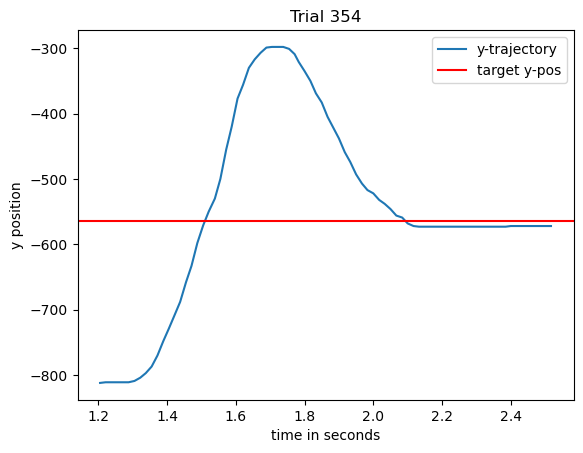

In [6]:
plot_trajectory(trial)